# Model Selection & Hyperparameter Tuning — Overfitting, GridSearchCV, RandomizedSearchCV

*Part of the ML Course Reference Series.*

## Q23: What is the difference between parameters and hyperparameters?

| | Parameters | Hyperparameters |
|---|---|---|
| **What** | Values the model learns from data | Values you choose before training |
| **Examples** | Decision tree split thresholds, linear regression weights | `max_depth`, `n_neighbors`, `C`, `alpha` |
| **How set** | Automatically during `.fit()` | Manually or via grid search |

Hyperparameters control model complexity and learning behaviour. Choosing them poorly causes underfitting or overfitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
sns.set_theme(style='whitegrid')
np.random.seed(42)
from sklearn.datasets import load_diabetes
_diab = load_diabetes(as_frame=True)
X_diab, y_diab = _diab.data, _diab.target
from sklearn.datasets import load_breast_cancer
_cancer = load_breast_cancer()
X_cancer, y_cancer = _cancer.data, _cancer.target
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


In [2]:
# After training, we can inspect the learned parameters
lr = LinearRegression()
lr.fit(X_diab, y_diab)

print('Learned parameters (coefficients):')
for feat, coef in zip(X_diab.columns, lr.coef_):
    print(f'  {feat:4s}: {coef:8.2f}')
print(f'  bias (intercept): {lr.intercept_:.2f}')
print()
print('Hyperparameters (you control these, not learned):')
print(' ', lr.get_params())

Learned parameters (coefficients):
  age :   -10.01
  sex :  -239.82
  bmi :   519.85
  bp  :   324.38
  s1  :  -792.18
  s2  :   476.74
  s3  :   101.04
  s4  :   177.06
  s5  :   751.27
  s6  :    67.63
  bias (intercept): 152.13

Hyperparameters (you control these, not learned):
  {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


## Q24: What is overfitting and underfitting?

```
                      Model Complexity →
Error
  │\                              /
  │  \   Underfitting            / Overfitting
  │    \_________________________/
  │              Sweet spot
  └──────────────────────────────────
```

- **Underfitting (high bias):** model too simple → fails on both train and test
- **Overfitting (high variance):** model too complex → great on train, poor on test
- **Signals:** large gap between train accuracy and CV/test accuracy = overfitting

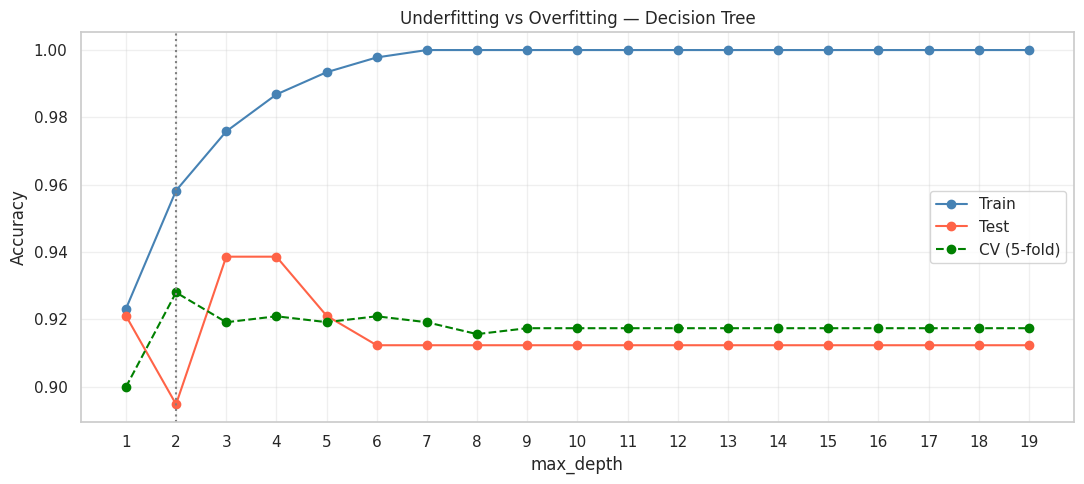

Best depth by CV: 2


In [3]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

depths = range(1, 20)
train_acc, test_acc, cv_acc = [], [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, dt.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, dt.predict(X_te)))
    cv_acc.append(cross_val_score(dt, X_cancer, y_cancer, cv=5).mean())

best_d = list(depths)[np.argmax(cv_acc)]

plt.figure(figsize=(11, 5))
plt.plot(depths, train_acc, marker='o', label='Train', color='steelblue')
plt.plot(depths, test_acc,  marker='o', label='Test',  color='tomato')
plt.plot(depths, cv_acc,    marker='o', label='CV (5-fold)', color='green', linestyle='--')
plt.axvline(best_d, color='gray', linestyle=':', linewidth=1.5)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Underfitting vs Overfitting — Decision Tree')
plt.legend()
plt.xticks(list(depths))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Best depth by CV: {best_d}')

## Q25: What is GridSearchCV and how does it work?

GridSearchCV exhaustively tries every combination of hyperparameters from a grid and evaluates each using cross-validation. It returns the combination with the best CV score.

**Naming inside a Pipeline:** use `stepname__param` — e.g. `'model__max_depth'`.

**Watch out:** with a large grid, the number of fits = `|combinations| × cv_folds`. 100 combinations × 5 folds = 500 model fits. Use `n_jobs=-1` to parallelise.

In [4]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scl',   StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': [3, 5, 7, 11, 15, 21],
    'model__weights':     ['uniform', 'distance']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_cancer, y_cancer)

print('Best params: ', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 4))

Best params:  {'model__n_neighbors': 7, 'model__weights': 'uniform'}
Best CV score: 0.9701


## Q26: What is RandomizedSearchCV and when should you use it instead of GridSearchCV?

GridSearchCV tries **every combination**. With large grids this is expensive. RandomizedSearchCV samples a **random subset** of parameter combinations — you control how many via `n_iter`.

**Rule of thumb:** use `GridSearchCV` for small grids (< ~100 combos); use `RandomizedSearchCV` for large grids or when parameters span wide continuous ranges.

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

pipe = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

param_dist = {
    'model__n_estimators':      randint(50, 300),
    'model__max_depth':         [None, 3, 5, 7, 10],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf':  randint(1, 10)
}

rand_search = RandomizedSearchCV(
    pipe, param_dist, n_iter=20, cv=5,
    scoring='accuracy', random_state=42, n_jobs=-1
)
rand_search.fit(X_cancer, y_cancer)

print('Best params: ', rand_search.best_params_)
print('Best CV score:', round(rand_search.best_score_, 4))

Best params:  {'model__max_depth': 7, 'model__min_samples_leaf': 2, 'model__min_samples_split': 7, 'model__n_estimators': 103}
Best CV score: 0.9596


---
# 8. Probability & Statistics